# Jupyter Notebooks

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df = pd.read_csv("/content/Customer Churn.csv")

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df["TotalCharges"] = df["TotalCharges"].replace(" ","0")
df["TotalCharges"] = df["TotalCharges"].astype("float")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [ ]:
df["customerID"].duplicated().sum()

np.int64(0)

In [ ]:
def conv(value):
  if value == 1:
      return  "Yes"
  else:
      return "No"

In [ ]:
df['SeniorCitizen'] = df['SeniorCitizen'].apply(conv)

In [ ]:
# converted 0 and 1 values of Senior Citizen to yes/no to make it easier to understand

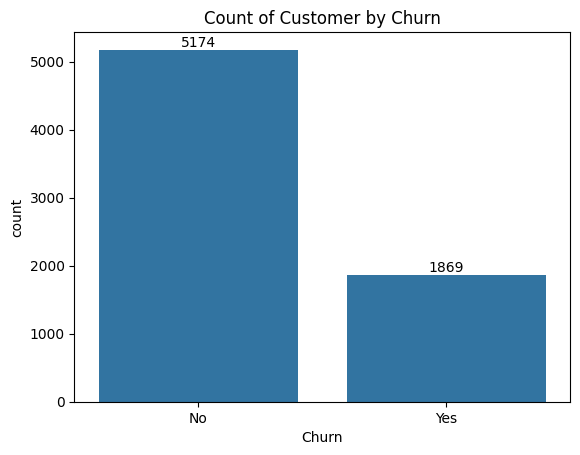

In [ ]:
ax = sns.countplot(x="Churn", data=df)
ax.bar_label(ax.containers[0])
plt.title('Count of Customer by Churn')
plt.show()

In [ ]:
gb = df.groupby("Churn").agg({'Churn': "count"})
gb

,Churn
Churn,
No,5174
Yes,1869


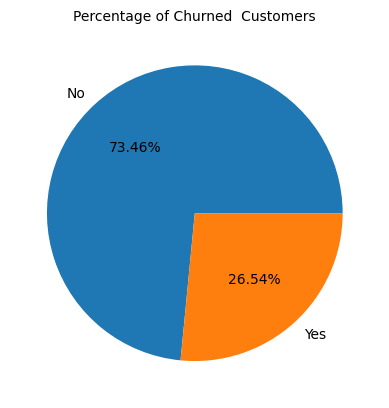

<Figure size 200x300 with 0 Axes>

<Figure size 200x300 with 0 Axes>

In [ ]:
plt.pie(gb['Churn'],labels=gb.index,autopct='%1.2f%%')
plt.title('Percentage of Churned  Customers', fontsize= 10)
plt.show()
plt.figure(figsize=(2,3))

In [ ]:
# from the given pie chart we can conclude that 26.54% of our customers have churned out
# now let's explore the reasion behind it

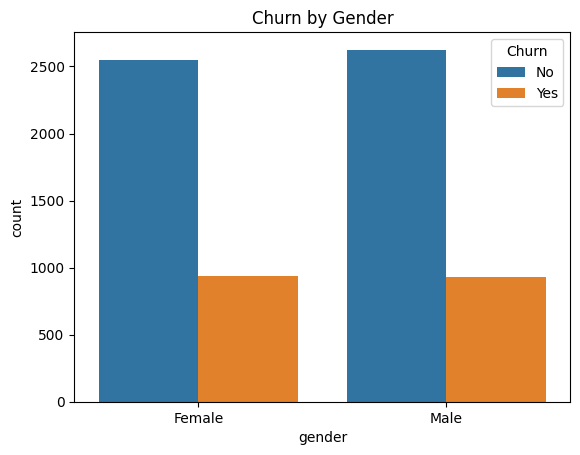

<Figure size 300x300 with 0 Axes>

<Figure size 300x300 with 0 Axes>

In [ ]:
sns.countplot(x = 'gender', data = df, hue = 'Churn')
plt.title("Churn by Gender")
plt.show()
plt.figure(figsize=(3,3))


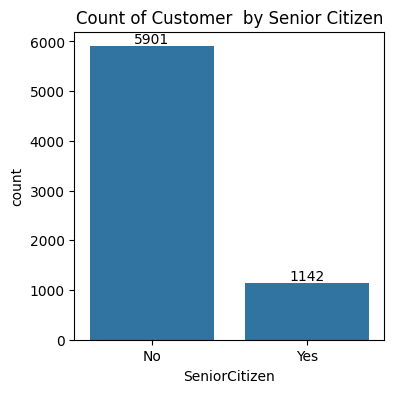

In [ ]:
plt.figure(figsize=(4,4))
ax = sns.countplot(x = "SeniorCitizen", data = df)
ax.bar_label(ax.containers[0])
plt.title("Count of Customer  by Senior Citizen")
plt.show()

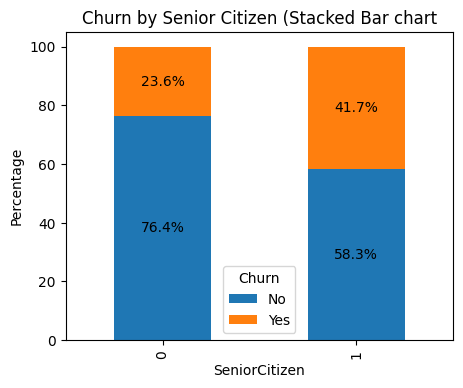

In [28]:
ct = pd.crosstab(df['SeniorCitizen'], df['Churn'])
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
ax = ct_pct.plot(kind='bar', stacked=True, figsize=(5,4))
plt.title("Churn by Senior Citizen (Stacked Bar chart")
plt.ylabel("Percentage")
plt.xlabel("SeniorCitizen")
for i in ax.containers:
    ax.bar_label(i, fmt='%.1f%%', label_type='center')
    plt.legend(title='Churn')
plt.show()

In [ ]:
# comparative a greater percentage of people in Senior Citizen category have chured.

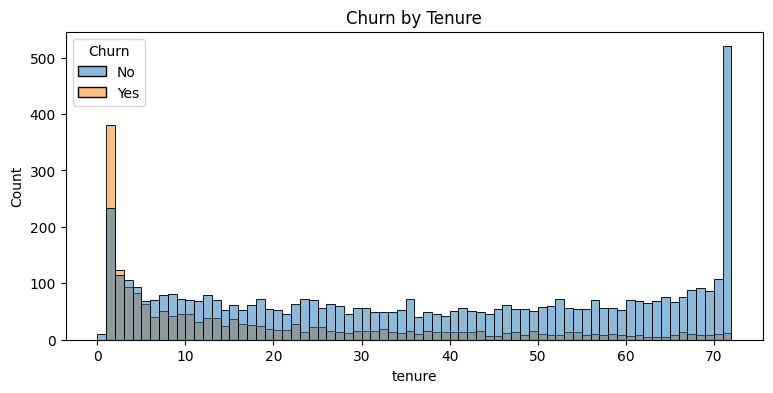

In [ ]:
plt.figure(figsize=(9,4))
sns.histplot(x = 'tenure', data= df, bins= 72, hue="Churn")
plt.title("Churn by Tenure")
plt.show()

In [ ]:
# pepole who have used our services for a long time have stayed and people who have used our services #1 or 2 months have churn

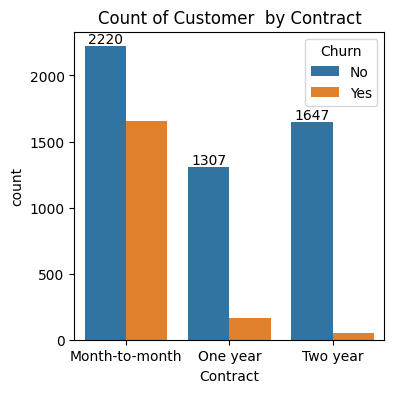

In [ ]:
plt.figure(figsize=(4,4))
ax = sns.countplot(x = "Contract", data = df, hue="Churn")
ax.bar_label(ax.containers[0])
plt.title("Count of Customer  by Contract")
plt.show()

In [ ]:
# people who have month contract are likely to churn then form those who have 1 or 2 years or contract

In [11]:
df.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

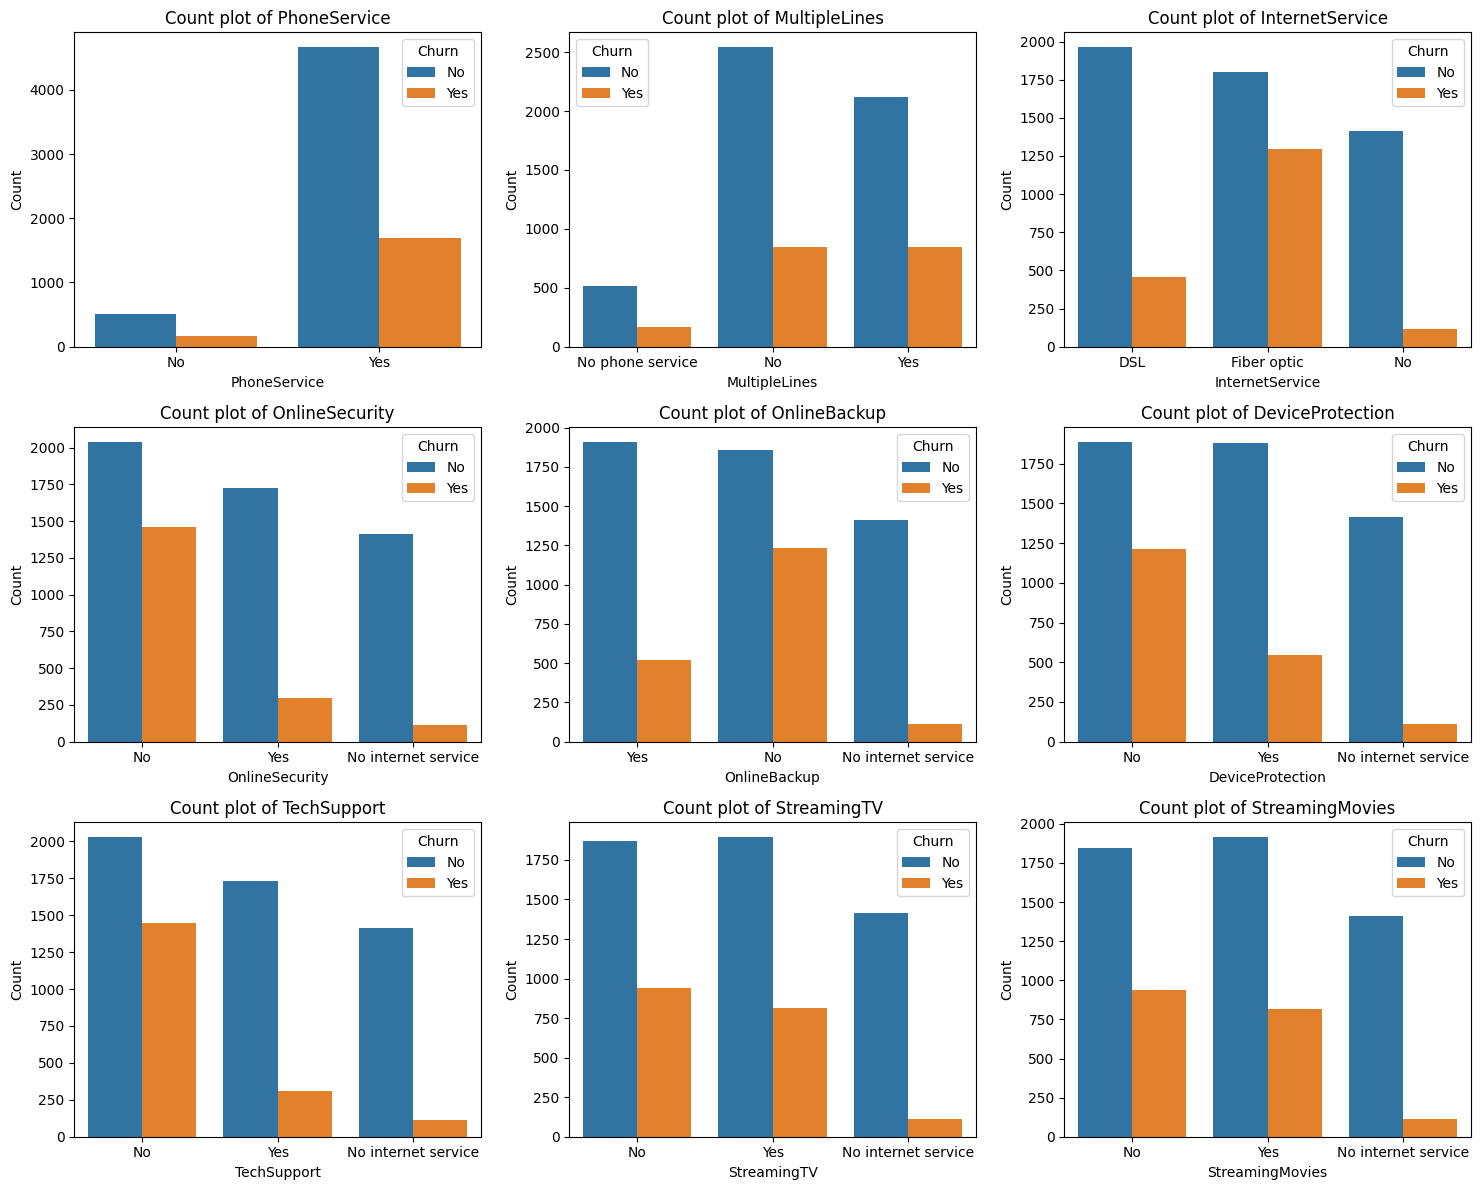

In [20]:

columns = ['PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies']
n_cols = 3
n_rows = (len(columns) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(columns):
    sns.countplot(x=col, data=df, ax=axes[i], hue = df['Churn'])
    axes[i].set_title(f'Count plot of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

for j in range(i +1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()



In [ ]:
# the majority of customers who do not chrun tend to have services like PhoneServices, InternetServices (particulary OSL) and online scurity enabled. For services like OnlineBackup, TechSuport and StreamingTV, churn rates are noticeably higher when these services are not used or
# Unable

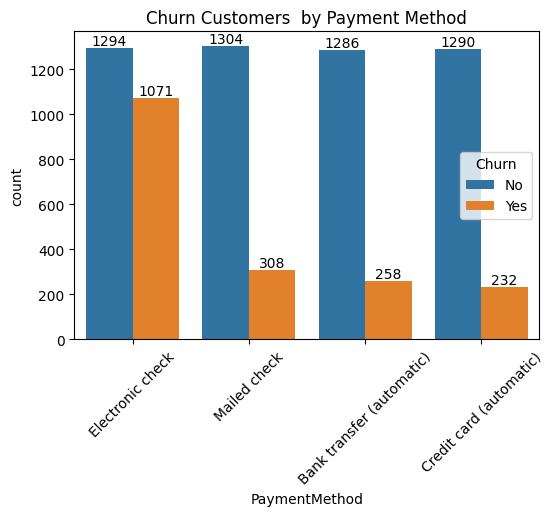

In [27]:
plt.figure(figsize=(6,4))
ax = sns.countplot(x = "PaymentMethod", data = df, hue="Churn")
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Churn Customers  by Payment Method")
plt.xticks(rotation=45)
plt.show()

In [ ]:
#customer is likely to churn when he is using electronic check as payment methode